# Read Motor Data With Zero Torque

This notebook sends zero torque for a fixed duration while you rotate the motor by hand. After recording, it plots motor history: continuous unwrapped position, raw wrapped position, velocity, and current.

Keep the motor mechanically safe: zero torque means the motor is not actively held.

In [1]:
from pathlib import Path
from datetime import datetime
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SCRIPT_DIR = Path.cwd() if Path.cwd().name == "scripts" else Path.cwd() / "scripts"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from motor_position import POS_PERIOD_RAD, rotation_check, unwrap_motor_position

import encosid

## Configuration

Set the motor interface/id and duration here. When ready to record, set `RUN_RECORDING = True`, run the recording cell, and rotate the motor by hand for `DURATION_S` seconds.

In [2]:
MOTOR_IF = "can0"

encosid.get_id(MOTOR_IF)
MOTOR_ID = encosid.get_id(MOTOR_IF)

DT_MS = 1
DURATION_S = 20

RUN_RECORDING = True
SAVE_CSV = False

USE_FACTORY_SCALES = False # False by default

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "data" / "manual"

Found id #513
Found id #4


In [3]:
def record_zero_torque(
    use_factory_scales: float = USE_FACTORY_SCALES,
    duration_s: float = DURATION_S,
    dt_ms: float = DT_MS,
    motor_if: str = MOTOR_IF,
    motor_id: int = MOTOR_ID,
) -> pd.DataFrame:
    sample_count = int(round(duration_s * 1000 / dt_ms))
    time_s = np.arange(sample_count, dtype=float) * dt_ms * 1e-3
    qact = np.zeros(sample_count, dtype=float)

    gen = encosid.SignalGenerator(motor_if, motor_id)
    gen.set_mode(gen.mode.torque, 0)
    gen.set_factory_scales(use_factory_scales)

    print(f"Recording {duration_s:.1f} s with zero torque ({sample_count} samples)...")
    qpos_raw, qvel, qcur, err = map(np.asarray, gen.play_signal(qact.tolist(), dt_ms))
    qpos = unwrap_motor_position(qpos_raw)
    print("Recording finished")

    return pd.DataFrame(
        {
            "time_s": time_s,
            "qpos": qpos,
            "qpos_raw": qpos_raw,
            "qvel": qvel,
            "qcur": qcur,
            "qact": qact,
            "err": err
        }
    )


def save_recording(df: pd.DataFrame, output_dir: Path = OUTPUT_DIR) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_path = output_dir / f"zero_torque_manual_{timestamp}.csv"
    df.to_csv(output_path, index=False)
    return output_path

## Record

Set `RUN_RECORDING = True`, start this cell, then rotate the motor by hand until the 20 second recording finishes.

In [4]:
if RUN_RECORDING:
    motor_history = record_zero_torque()
    if SAVE_CSV:
        saved_path = save_recording(motor_history)
        print(f"Saved recording to {saved_path}")
else:
    print("RUN_RECORDING is False. Set it to True when you are ready to record.")
    motor_history = pd.DataFrame()

Recording 20.0 s with zero torque (20000 samples)...
Recording finished


In [5]:
if motor_history.empty:
    print("No motor history recorded yet.")
else:
    display(motor_history.head())
    display(motor_history.tail())

print(set(motor_history["err"]))

,time_s,qpos,qpos_raw,qvel,qcur,qact,err
0,0.000,-3.159228,-3.159228,0.000000,0.000000,0.0,NoError
1,0.001,-3.159228,-3.159228,0.000000,0.000000,0.0,NoError
2,0.002,-3.159228,-3.159228,0.000000,0.043957,0.0,NoError
3,0.003,-3.159228,-3.159228,-0.009768,0.000000,0.0,NoError
4,0.004,-3.159228,-3.159228,0.000000,0.000000,0.0,NoError


,time_s,qpos,qpos_raw,qvel,qcur,qact,err
19995,19.995,-9.434348,-9.434348,-0.009768,0.043957,0.0,NoError
19996,19.996,-9.434348,-9.434348,0.000000,-0.073259,0.0,NoError
19997,19.997,-9.434348,-9.434348,0.000000,-0.029305,0.0,NoError
19998,19.998,-9.434653,-9.434653,-0.009768,-0.073259,0.0,NoError
19999,19.999,-9.434653,-9.434653,0.009768,-0.014652,0.0,NoError


{'NoError'}


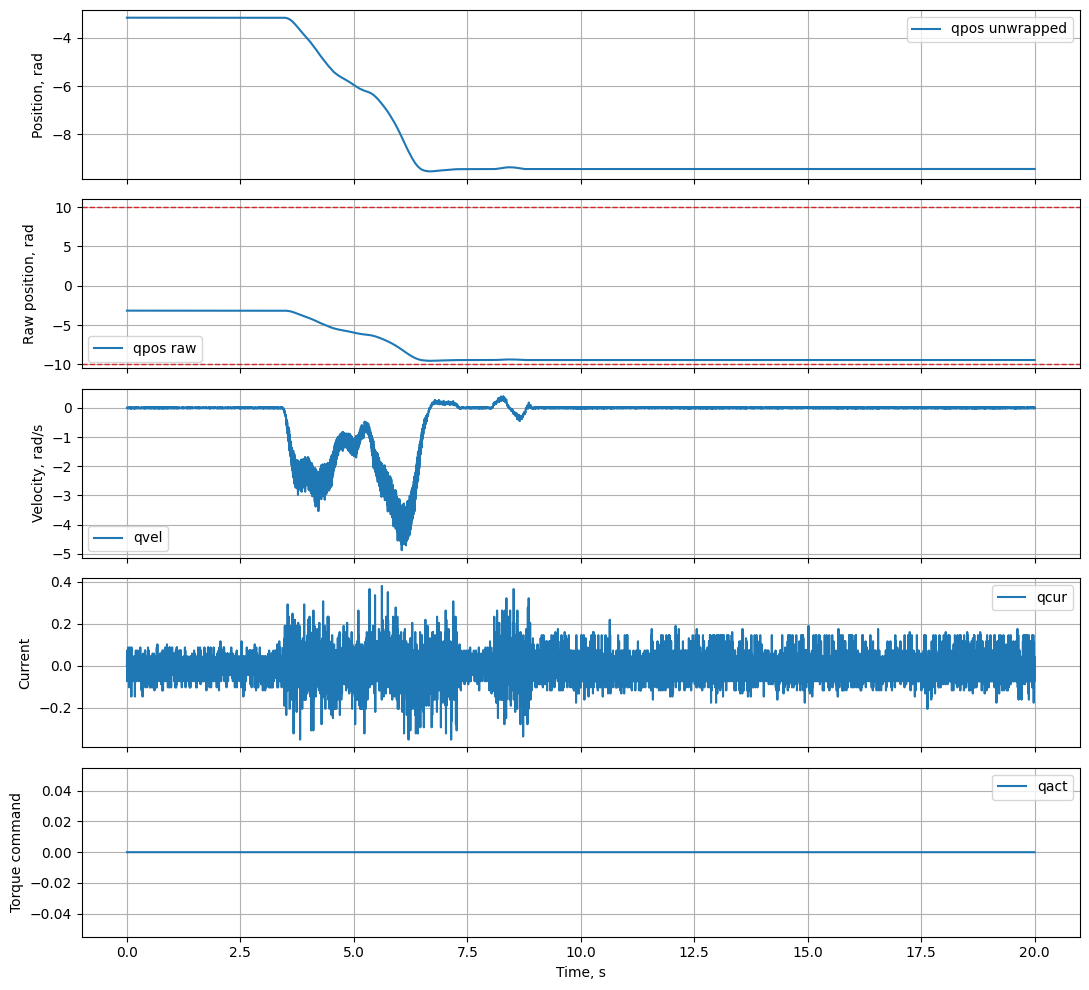

In [6]:
if not motor_history.empty:
    fig, ax = plt.subplots(5, 1, figsize=(11, 10), sharex=True)

    ax[0].plot(motor_history["time_s"], motor_history["qpos"], label="qpos unwrapped")
    ax[0].set_ylabel("Position, rad")

    ax[1].plot(motor_history["time_s"], motor_history["qpos_raw"], label="qpos raw")
    ax[1].set_ylabel("Raw position, rad")
    ax[1].axhline(POS_PERIOD_RAD / 2, color="tab:red", linestyle="--", linewidth=1)
    ax[1].axhline(-POS_PERIOD_RAD / 2, color="tab:red", linestyle="--", linewidth=1)

    ax[2].plot(motor_history["time_s"], motor_history["qvel"], label="qvel")
    ax[2].set_ylabel("Velocity, rad/s")

    ax[3].plot(motor_history["time_s"], motor_history["qcur"], label="qcur")
    ax[3].set_ylabel("Current")

    ax[4].plot(motor_history["time_s"], motor_history["qact"], label="qact")
    ax[4].set_ylabel("Torque command")
    ax[4].set_xlabel("Time, s")

    for axis in ax:
        axis.grid()
        axis.legend()

    plt.tight_layout()
    plt.show()

## Rotation Scale Check

After recording, set how many full rotations you made by hand. Use `DIRECTION = 1` if the unwrapped position increased, or `-1` if it decreased.

In [7]:
N_ROTATIONS = 1
DIRECTION = 1

if motor_history.empty:
    print("No motor history recorded yet.")
else:
    check = rotation_check(
        motor_history["qpos_raw"].to_numpy(),
        n_rotations=N_ROTATIONS,
        direction=DIRECTION,
    )
    print(f"Position feedback period used for unwrap: {POS_PERIOD_RAD:.6f} rad")
    print(f"Measured delta: {check['measured_delta_rad']:.6f} rad")
    print(f"Expected delta: {check['expected_delta_rad']:.6f} rad")
    print(f"Error:          {check['error_rad']:.6f} rad")
    print(f"Error/turn:     {check['error_per_turn_rad']:.6f} rad")
    print(f"Scale:          {check['scale']:.6f}")

Position feedback period used for unwrap: 20.000000 rad
Measured delta: -6.275425 rad
Expected delta: 6.283185 rad
Error:          -12.558611 rad
Error/turn:     -12.558611 rad
Scale:          -0.998765


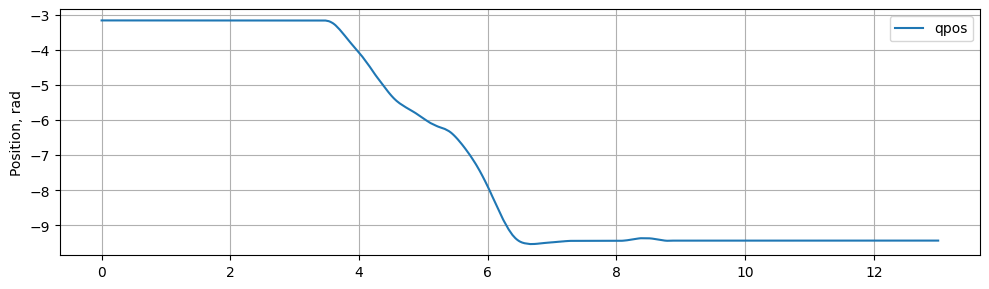

-3.1592278480529785 -9.53414249420166
6.374914646148682
2.029198355446967


In [8]:
START, END = 0,13000
if not motor_history.empty:
    fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

    ax.plot(motor_history["time_s"][START:END], motor_history["qpos"][START:END], label="qpos")
    ax.set_ylabel("Position, rad")

    # for axis in ax:
    ax.grid()
    ax.legend()

    plt.tight_layout()
    plt.show()
    print(motor_history["qpos"][START:END].max(),motor_history["qpos"][START:END].min())
    print(motor_history["qpos"][START:END].max()-motor_history["qpos"][START:END].min())
    print((motor_history["qpos"][START:END].max()-motor_history["qpos"][START:END].min())/np.pi)

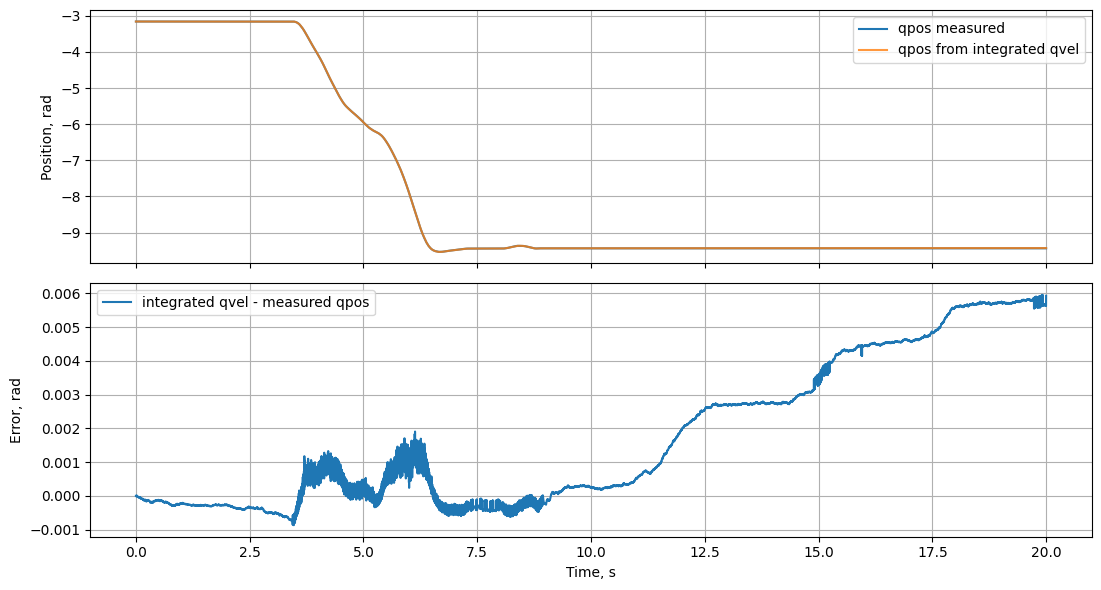

Measured qpos delta:       -6.275425 rad
Integrated qvel delta:     -6.269495 rad
Final integration error:   0.005931 rad
Mean absolute error:       0.001924 rad
Max absolute error:        0.005960 rad


In [9]:
if motor_history.empty:
    print("No motor history recorded yet.")
else:
    time_s = motor_history["time_s"].to_numpy(dtype=float)
    qvel = motor_history["qvel"].to_numpy(dtype=float)
    qpos = motor_history["qpos"].to_numpy(dtype=float)

    dt_s = np.diff(time_s)
    qpos_from_qvel = np.empty_like(qpos)
    qpos_from_qvel[0] = qpos[0]
    qpos_from_qvel[1:] = qpos[0] + np.cumsum(0.5 * (qvel[:-1] + qvel[1:]) * dt_s)

    qpos_error = qpos_from_qvel - qpos
    qpos_delta = qpos[-1] - qpos[0]
    qvel_delta = qpos_from_qvel[-1] - qpos_from_qvel[0]

    fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    ax[0].plot(time_s, qpos, label="qpos measured")
    ax[0].plot(time_s, qpos_from_qvel, label="qpos from integrated qvel", alpha=0.8)
    ax[0].set_ylabel("Position, rad")
    ax[0].grid()
    ax[0].legend()

    ax[1].plot(time_s, qpos_error, label="integrated qvel - measured qpos")
    ax[1].set_xlabel("Time, s")
    ax[1].set_ylabel("Error, rad")
    ax[1].grid()
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Measured qpos delta:       {qpos_delta:.6f} rad")
    print(f"Integrated qvel delta:     {qvel_delta:.6f} rad")
    print(f"Final integration error:   {qpos_error[-1]:.6f} rad")
    print(f"Mean absolute error:       {np.mean(np.abs(qpos_error)):.6f} rad")
    print(f"Max absolute error:        {np.max(np.abs(qpos_error)):.6f} rad")